# Test effect of changing bomb spread with default SNEC model

Compare explosions/collapse of the default $15M_{\odot}$ star shipped
with SNEC using $E_{\rm expl}=0$ (that is $E_{bomb}=-BE$) and varying
the mass interval over which the bomb is applied 

author: [Mathieu Renzo](mrenzo@arizona.edu)

In [1]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import (SNEC_output_parser, plot_LC, plot_vel_mass_at_time_t,
                      get_times, plot_vel_radius_at_time_t,
                      plot_rho_pfile, get_innerBC_t)
import astropy.units as u
import re
import glob
from itertools import cycle
from matplotlib.colors import LinearSegmentedColormap
%load_ext autoreload
%autoreload 2

Hardcoded some constants


In [2]:
def get_bomb_spread(folder):
    spread = np.nan
    fname = folder+'/parameters'
    with open(fname, 'r') as f:
        for i, line in enumerate(f):
            # print(line)
            if ("bomb_mass_spread" in line) and ('/' not in line):
                found = re.search(r'=\s*([\d.]+(?:[deDE][+-]?\d+)?)', line)
                if found:
                    spread = float(found.group(1).replace('d', 'e').replace('D', 'e'))
                break
    return spread * u.Msun


# for m in models:
#     print(get_bomb_spread(m))

In [3]:
root = "/home/mrenzo/Runs/SNEC_grid/bomb_spread/15Msun/"
models = sorted(glob.glob(root+'*/'), key=get_bomb_spread)
# for m in models: print(m)

colors = plt.cm.viridis(np.linspace(0,1,len(models)))
print(len(models))

14


/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:406: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


Text(0.5, 1.0, '$E_{\\rm bomb} = - BE$')

/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  func(*args, **kwargs)
/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


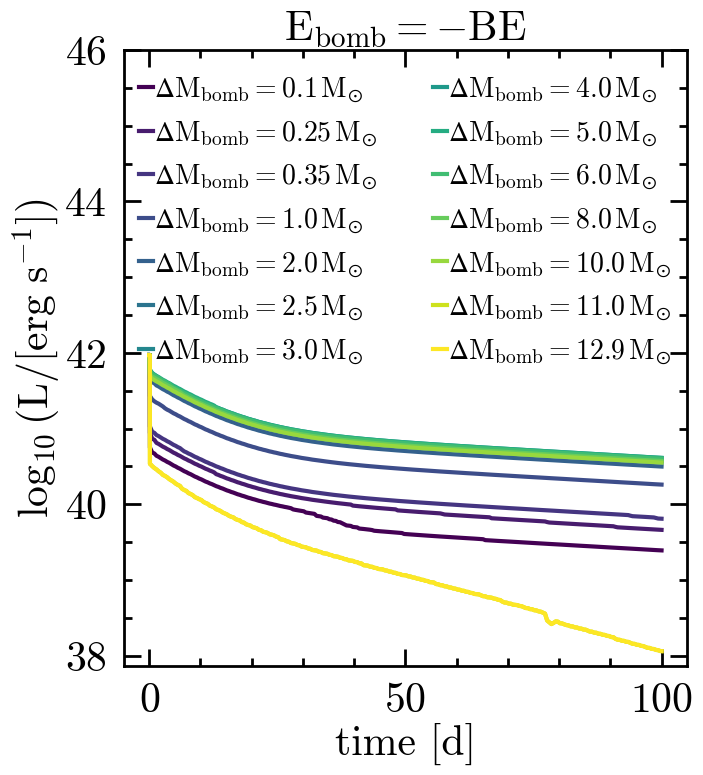

In [4]:
# light curves

fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])

for i, mod in enumerate(models):
    fname = mod+'/Data/lum_observed.dat'
    L, t = plot_LC(fname, ax=ax, c=colors[i],
                   label=r"$\Delta M_{\rm bomb}="+f"{get_bomb_spread(mod).value}"+r"\,M_{\odot}$")

ax.legend(ncol=2, fontsize=20, handlelength=0.5, handletextpad=0.05, loc="upper center")
ax.set_xlabel(r"time [d]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")
ax.set_ylim(ymax=46)
ax.set_title(r"$E_{\rm bomb} = - BE$", size=30)
# ax.set_xlim(0, 0.25)

In [ ]:
# radius vs. time for given mass coordinate

fig = plt.figure(figsize=(13,10))
gs = gridspec.GridSpec(14, 110)
# axes = [fig.add_subplot(gs[i, :100]) for i in range(len(models[:2]))]
# axes [fig.add_subplot(gs[:7, :100]),fig.add_subplot(gs[7:, :100])]
ax1 = fig.add_subplot(gs[:7, :100])
ax2 = fig.add_subplot(gs[7:, :100])
axes = [ax1,ax2]
cax = fig.add_subplot(gs[:, 105:])

tmax = 24*u.h
# define colormap -- to use time in hours as color value
Ncolors = 10
colors = plt.get_cmap('viridis', Ncolors)
norm = mpl.colors.Normalize(vmin=0,vmax=tmax.to(u.h).value)


sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
sm.set_array([])

for i, mod in enumerate([models[0], models[-2]]):
    print(mod)
    ax = axes[i]
    vel_out = mod+'/Data/vel.xg'
    times = get_times(mod+'Data/mass.xg')
    tiBC, iBC = get_innerBC_t(mod+'/Data/inner_boundary.dat')
    ax.text(0.05, 0.1, r"$\Delta M_{\rm bomb}="+f"{get_bomb_spread(mod).value}"+r"\,M_{\odot}$",
            fontsize=30, transform=ax.transAxes, ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.02", facecolor="white", edgecolor="#808080", alpha=0.8))
    for j, tt in enumerate(times):
        if (tt.to(u.h)>= tmax): break
        color = colors(norm(tt.to(u.h).value))
        mass, vel, p = plot_vel_mass_at_time_t(tt, vel_out, ax=ax, scatter=False, c=color)
        k = np.argmin(np.absolute(tiBC.to(u.h)-tt.to(u.h)))
        iBC_t = iBC[k]
        ax.axvline(mass[iBC_t].to(u.Msun).value, c=color, ls='--', zorder=0, lw='2')

plt.colorbar(sm, cax=cax, # ticks=np.linspace(0,2,N), 
             # boundaries=np.arange(-0.05,2.1,.1)
             )
cax.set_ylabel(r"time [h]")
ax1.set_title(r"$15\,M_{\odot}\overset{\mathrm{wind}}{\rightarrow} 12.3\,M_{\odot},\ E_{\rm bomb} = BE_{\star} \Rightarrow E_{\rm expl}=0$", size=30)
ax1.set_xticklabels([])
ax2.set_xlabel(r"mass $[M_{\odot}]$")
fig.text(0.01, 0.5, r"velocity $[\mathrm{km\ s^{-1}}]$", va='center', rotation='vertical', size=30)

for ax in axes:
    ax.set_xlim(0, 8)
    ax.axvspan(0, 1.4, color="#808080", alpha=0.5, zorder=0)

plt.savefig(root+"/bomb_comparison_two_models_vel_vs_m.pdf")

/home/mrenzo/Runs/SNEC_grid/bomb_spread/15Msun/bomb_mass_spread_0.1d0/


In [69]:
def map_mass_radius(mass_x, mass_r, r):
    i = np.argmin(np.absolute(mass_x.to(u.Msun)-mass_r.to(u.Msun)))
    return  r[i]

In [ ]:
# now in radius

fig = plt.figure(figsize=(13,10))
gs = gridspec.GridSpec(14, 110)
# axes = [fig.add_subplot(gs[i, :100]) for i in range(len(models[:2]))]
# axes [fig.add_subplot(gs[:7, :100]),fig.add_subplot(gs[7:, :100])]
ax1 = fig.add_subplot(gs[:7, :100])
ax2 = fig.add_subplot(gs[7:, :100])
axes = [ax1,ax2]
cax = fig.add_subplot(gs[:, 105:])

tmax = 24*u.h
# define colormap -- to use time in hours as color value
Ncolors = 10
colors = plt.get_cmap('viridis', Ncolors)
norm = mpl.colors.Normalize(vmin=0,vmax=tmax.to(u.h).value)


sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
sm.set_array([])

for i, mod in enumerate([models[0], models[-2]]):
    print(mod)
    ax = axes[i]
    vel_out = mod+'/Data/vel.xg'
    mass_out = mod+'Data/mass.xg'
    times = get_times(mod+'Data/mass.xg')
    tiBC, iBC = get_innerBC_t(mod+'/Data/inner_boundary.dat')
    ax.text(0.05, 0.1, r"$\Delta M_{\rm bomb}="+f"{get_bomb_spread(mod).value}"+r"\,M_{\odot}$",
            fontsize=30, transform=ax.transAxes, ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.02", facecolor="white", edgecolor="#808080", alpha=0.8))
    for j, tt in enumerate(times):
        if (tt.to(u.h)>= tmax): break
        color = colors(norm(tt.to(u.h).value))
        radius, vel, p = plot_vel_radius_at_time_t(tt, vel_out, mass_out, ax=ax, scatter=False, c=color)
        k = np.argmin(np.absolute(tiBC.to(u.h)-tt.to(u.h)))
        iBC_t = iBC[k]
        ax.axvline(np.log10(radius[iBC_t].to(u.cm).value), c=color, ls='--', zorder=0, lw='2')

plt.colorbar(sm, cax=cax, # ticks=np.linspace(0,2,N), 
             # boundaries=np.arange(-0.05,2.1,.1)
             )
cax.set_ylabel(r"time [h]")
ax1.set_title(r"$15\,M_{\odot}\overset{\mathrm{wind}}{\rightarrow} 12.3\,M_{\odot},\ E_{\rm bomb} = BE_{\star} \Rightarrow E_{\rm expl}=0$", size=30)
ax1.set_xticklabels([])
ax2.set_xlabel(r"$\log_{10}(r/\mathrm{[cm]})$")
fig.text(0.01, 0.5, r"velocity $[\mathrm{km\ s^{-1}}]$", va='center', rotation='vertical', size=30)

for ax in axes:
    ax.set_xlim(7.8, 13)
    ax.axvspan(0, 1.4, color="#808080", alpha=0.5, zorder=0)

plt.savefig(root+"/bomb_comparison_two_models_vel_vs_r.pdf")